# Seasonal Agriculture Performance Analysis

**VOIS AICTE Data Analytics Internship — Major Project**

### Project objective
Analyze agricultural data across **Kharif, Rabi and Zaid** seasons to identify meaningful patterns, trends, relationships and differences in agricultural performance.

This notebook covers:
- Dataset understanding and data-quality checks
- Data cleaning and preparation
- Seasonal comparisons
- Environmental, resource-use and agricultural-performance analysis
- Economic performance analysis
- Relationships between conditions, resources and outcomes
- Statistical validation of important seasonal differences
- Key findings, conclusions and data-driven recommendations

> **Note:** The project brief asks for data analytics, statistical techniques and visualization. A machine-learning model is not required for this project, so this notebook focuses on evidence-based analysis rather than adding an unnecessary prediction model.


In [4]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Loading of the dataset

In [5]:
# Load dataset
df=pd.read_csv('/content/seasonal_agriculture_performance_dataset.csv')

print('Dataset loaded succesfully')

Dataset loaded succesfully


## 2. Understanding the dataset

The dataset contains information about:
- **Farm and location:** Farm ID, State, District, Crop, Season
- **Environmental conditions:** rainfall, temperature, humidity, sunlight
- **Soil and nutrients:** pH, moisture, nitrogen, phosphorus, potassium
- **Farming practices:** irrigation, fertilizer, pesticide and seed quality
- **Agricultural outcomes:** yield and production
- **Economic outcomes:** market price, cost, revenue and profit
- **Resource/risk indicators:** water usage, water efficiency and disease/pest risk


In [6]:
# Basic structure and data types
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

Rows: 4000
Columns: 28

Data types:


,Data Type
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


## 2.1 Top 5 Rows — Initial Data Check

The project checklist requires the first five records to be examined before analysis. This confirms that the dataset has loaded correctly and gives an initial view of the records.

In [8]:
# Display the first five records
df.head(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [10]:
# Summary statistics
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF13984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,4000.0,NaN,NaN,NaN,7.888265,4.223764,0.5,4.26,7.895,11.65,15.0
Rainfall_mm,3952.0,NaN,NaN,NaN,601.152657,288.925025,80.0,370.2,582.0,834.95,1395.2
Avg_Temperature_C,4000.0,NaN,NaN,NaN,26.8189,3.81818,16.2,23.9,26.9,29.6,39.7
Humidity_pct,4000.0,NaN,NaN,NaN,63.2105,11.960834,25.0,54.775,63.0,71.9,95.0
Sunlight_Hours_Day,4000.0,NaN,NaN,NaN,7.32305,1.121186,3.5,6.6,7.3,8.1,11.0


In [11]:
# Unique values in important categorical columns
categorical_cols = ["State", "District", "Crop", "Season", "Irrigation_Method"]

for col in categorical_cols:
    print(f"\n{col}: {df[col].nunique()} unique values")
    df[col].value_counts().head(10)



State: 8 unique values

District: 10 unique values

Crop: 8 unique values

Season: 3 unique values

Irrigation_Method: 4 unique values


## 3. Data quality check and cleaning

We first identify missing values and duplicates. Missing numeric values are imputed using the **median**, which is less sensitive to extreme values than the mean. Duplicate rows are removed if present.

In [12]:
# Missing values and duplicates
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]

print("Missing values:")
display(missing.to_frame("Missing Count"))

print(f"\nDuplicate rows: {df.duplicated().sum():,}")


Missing values:


,Missing Count
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32



Duplicate rows: 0


In [13]:
# Clean the dataset
df_clean = df.copy()

# Remove exact duplicate records
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

# Impute missing numeric values with median
numeric_cols = df_clean.select_dtypes(include=np.number).columns
for col in numeric_cols:
    if df_clean[col].isna().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Ensure categorical fields are treated as strings
for col in categorical_cols:
    df_clean[col] = df_clean[col].astype("string")

print(f"Cleaned dataset shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print("Remaining missing values:", df_clean.isna().sum().sum())


Cleaned dataset shape: 4,000 rows × 28 columns
Remaining missing values: 0


## 4. Outlier Investigation

Outliers are investigated because unusually high or low values can affect averages, correlations and other statistical summaries. The IQR method is used as a screening technique.

An outlier is **not automatically an error**. The records are retained unless there is evidence that they are invalid.

In [15]:
# IQR-based outlier screening for important numeric variables
outlier_cols = [
    "Farm_Area_Hectares", "Rainfall_mm", "Yield_Tonnes_Ha",
    "Production_Tonnes", "Profit_INR", "Water_Used_m3"
]

outlier_rows = []
for col in outlier_cols:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (df_clean[col] < lower) | (df_clean[col] > upper)
    outlier_rows.append({
        "Variable": col, "Q1": q1, "Q3": q3,
        "Lower Bound": lower, "Upper Bound": upper,
        "Outlier Count": int(mask.sum()), "Outlier %": mask.mean()*100
    })

outlier_summary = pd.DataFrame(outlier_rows)
outlier_summary.round(2)

,Variable,Q1,Q3,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,Farm_Area_Hectares,4.26,11.65,-6.83,22.74,0,0.00
1,Rainfall_mm,371.58,831.98,-319.02,1522.57,0,0.00
2,Yield_Tonnes_Ha,1.05,2.83,-1.62,5.50,302,7.55
3,Production_Tonnes,5.02,24.36,-23.98,53.36,333,8.33
4,Profit_INR,-148731.75,216187.75,-696111.00,763567.00,404,10.10
5,Water_Used_m3,2268.75,7829.75,-6072.75,16171.25,276,6.90


### Outlier Visualizations

Each variable is plotted separately at a larger size so that the distribution and potential outliers are easy to inspect. For highly right-skewed variables, a second log-scale view is included where helpful.

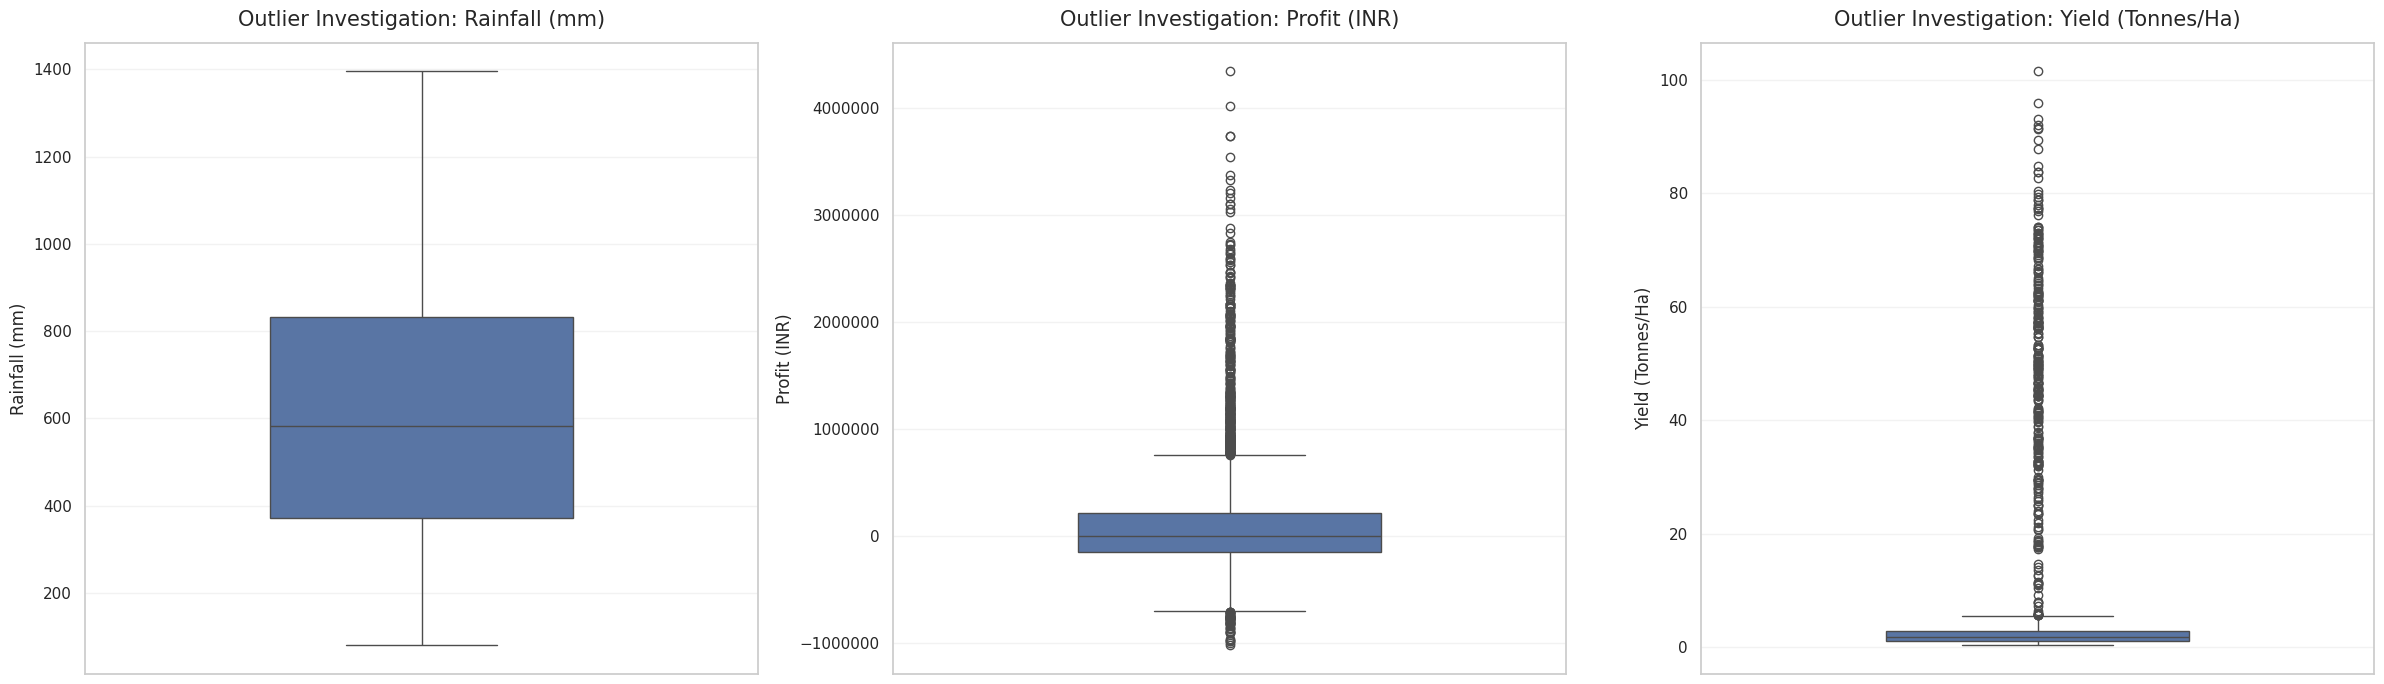

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# Plot Rainfall
sns.boxplot(y=df_clean["Rainfall_mm"], ax=axes[0], width=0.45)
axes[0].set_title("Outlier Investigation: Rainfall (mm)", fontsize=15, pad=12)
axes[0].set_ylabel("Rainfall (mm)", fontsize=12)
axes[0].grid(axis="y", alpha=0.25)

# Plot Profit
sns.boxplot(y=df_clean["Profit_INR"], ax=axes[1], width=0.45)
axes[1].set_title("Outlier Investigation: Profit (INR)", fontsize=15, pad=12)
axes[1].set_ylabel("Profit (INR)", fontsize=12)
axes[1].ticklabel_format(style="plain", axis="y")
axes[1].grid(axis="y", alpha=0.25)

# Plot Yield
sns.boxplot(y=df_clean["Yield_Tonnes_Ha"], ax=axes[2], width=0.45)
axes[2].set_title("Outlier Investigation: Yield (Tonnes/Ha)", fontsize=15, pad=12)
axes[2].set_ylabel("Yield (Tonnes/Ha)", fontsize=12)
axes[2].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

## 5. Univariate Analysis

Univariate analysis examines one variable at a time. It helps establish the basic distribution of seasonal records and key numeric variables before studying relationships between variables.

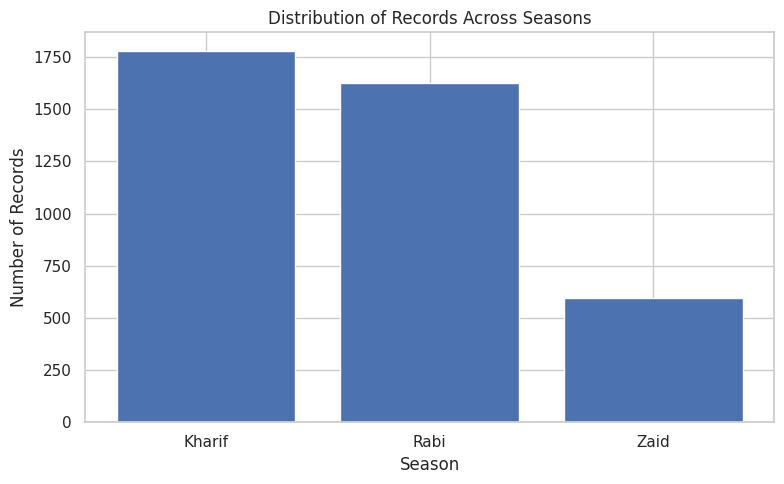

,Record Count
Season,
Kharif,1779
Rabi,1627
Zaid,594


In [23]:
# Univariate analysis: distribution of records across seasons
season_order = ["Kharif", "Rabi", "Zaid"]
season_counts_uni = df_clean["Season"].value_counts().reindex(season_order)

plt.figure(figsize=(8, 5))
plt.bar(season_counts_uni.index, season_counts_uni.values)
plt.title("Distribution of Records Across Seasons")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

season_counts_uni.to_frame("Record Count")

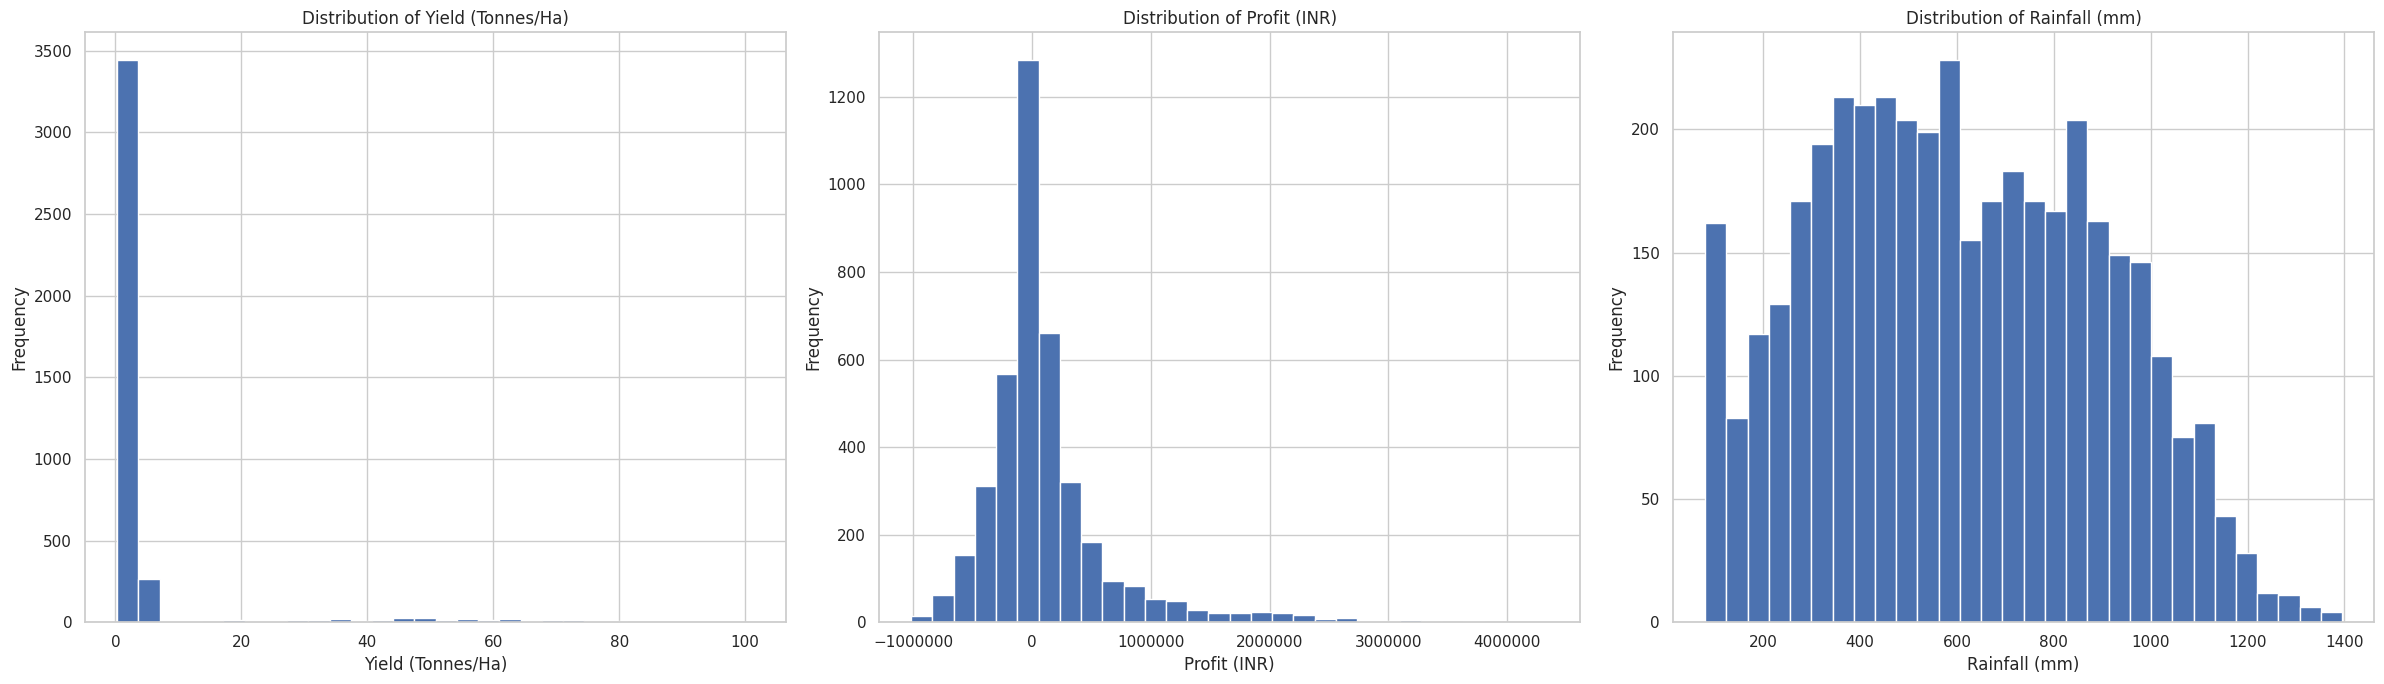

In [27]:
# Univariate analysis: key numeric distributions
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# Histogram for Yield_Tonnes_Ha
axes[0].hist(df_clean["Yield_Tonnes_Ha"].dropna(), bins=30)
axes[0].set_title("Distribution of Yield (Tonnes/Ha)")
axes[0].set_xlabel("Yield (Tonnes/Ha)")
axes[0].set_ylabel("Frequency")

# Histogram for Profit_INR
axes[1].hist(df_clean["Profit_INR"].dropna(), bins=30)
axes[1].set_title("Distribution of Profit (INR)")
axes[1].set_xlabel("Profit (INR)")
axes[1].set_ylabel("Frequency")
axes[1].ticklabel_format(style="plain", axis="x")

# Histogram for Rainfall_mm
axes[2].hist(df_clean["Rainfall_mm"].dropna(), bins=30)
axes[2].set_title("Distribution of Rainfall (mm)")
axes[2].set_xlabel("Rainfall (mm)")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## 6. Seasonal Distribution

The first key question is whether the dataset contains similar numbers of observations for each season.

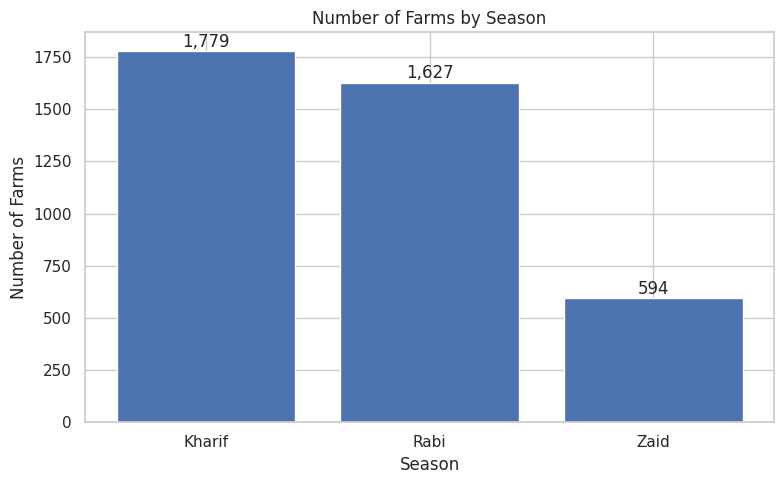

,Farm Count
Season,
Kharif,1779
Rabi,1627
Zaid,594


In [28]:
season_counts = df_clean["Season"].value_counts().reindex(["Kharif", "Rabi", "Zaid"])

plt.figure(figsize=(8, 5))
plt.bar(season_counts.index, season_counts.values)
plt.title("Number of Farms by Season")
plt.xlabel("Season")
plt.ylabel("Number of Farms")
for i, v in enumerate(season_counts.values):
    plt.text(i, v + 20, f"{v:,}", ha="center")
plt.tight_layout()
plt.show()

display(season_counts.to_frame("Farm Count"))

## 7. Bivariate Analysis

Bivariate analysis examines relationships between two variables. These comparisons focus on season versus environmental conditions, rainfall versus yield, and fertilizer use versus yield.

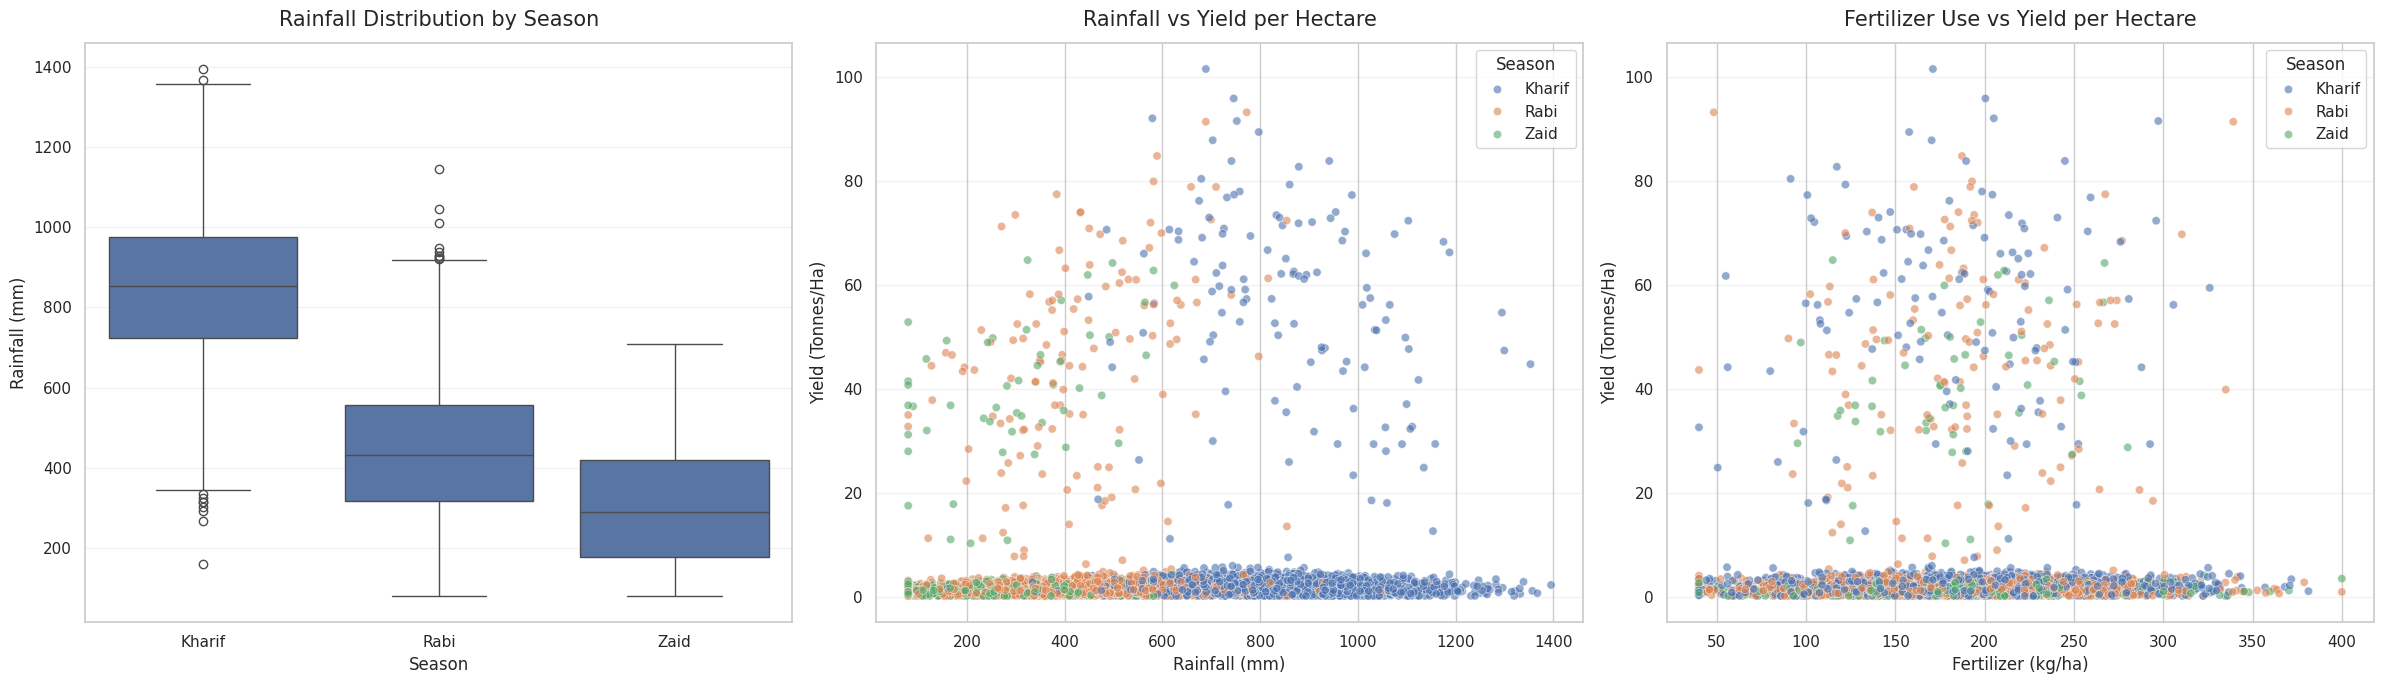

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# Season vs rainfall
sns.boxplot(data=df_clean, x="Season", y="Rainfall_mm", order=season_order, ax=axes[0])
axes[0].set_title("Rainfall Distribution by Season", fontsize=15, pad=12)
axes[0].set_xlabel("Season", fontsize=12)
axes[0].set_ylabel("Rainfall (mm)", fontsize=12)
axes[0].grid(axis="y", alpha=0.25)

# Rainfall vs yield
sns.scatterplot(data=df_clean, x="Rainfall_mm", y="Yield_Tonnes_Ha", hue="Season", alpha=0.6, ax=axes[1])
axes[1].set_title("Rainfall vs Yield per Hectare", fontsize=15, pad=12)
axes[1].set_xlabel("Rainfall (mm)", fontsize=12)
axes[1].set_ylabel("Yield (Tonnes/Ha)", fontsize=12)
axes[1].grid(axis="y", alpha=0.25)

# Fertilizer vs yield
sns.scatterplot(data=df_clean, x="Fertilizer_kg_ha", y="Yield_Tonnes_Ha", hue="Season", alpha=0.6, ax=axes[2])
axes[2].set_title("Fertilizer Use vs Yield per Hectare", fontsize=15, pad=12)
axes[2].set_xlabel("Fertilizer (kg/ha)", fontsize=12)
axes[2].set_ylabel("Yield (Tonnes/Ha)", fontsize=12)
axes[2].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

## 8. Environmental Conditions Across Seasons

Compare rainfall, temperature, humidity, sunlight and soil moisture to understand how seasonal conditions differ.

In [33]:
environmental_cols = [
    "Rainfall_mm", "Avg_Temperature_C", "Humidity_pct",
    "Sunlight_Hours_Day", "Soil_Moisture_pct"
]

season_env = df_clean.groupby("Season")[environmental_cols].mean().reindex(["Kharif", "Rabi", "Zaid"])
season_env.round(2)

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,849.20,28.45,71.81,6.79,31.15
Rabi,437.62,23.49,57.89,7.59,24.07
Zaid,304.65,31.04,52.01,8.18,19.28


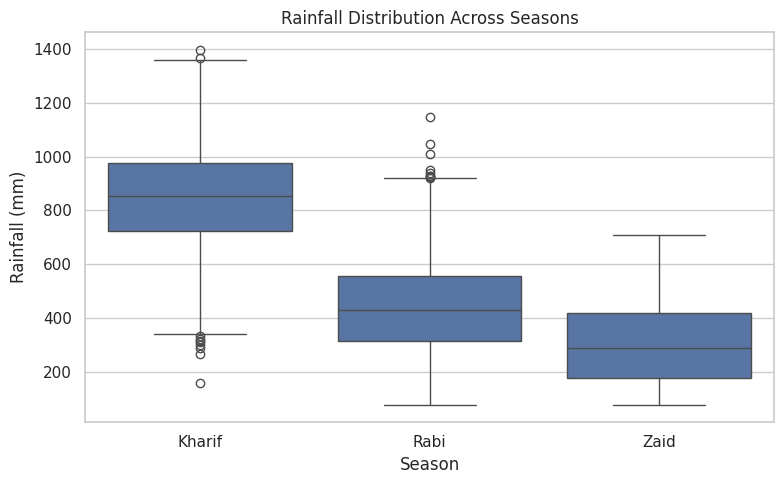

In [34]:
# Rainfall by season
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x="Season", y="Rainfall_mm", order=["Kharif", "Rabi", "Zaid"])
plt.title("Rainfall Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Rainfall (mm)")
plt.tight_layout()
plt.show()


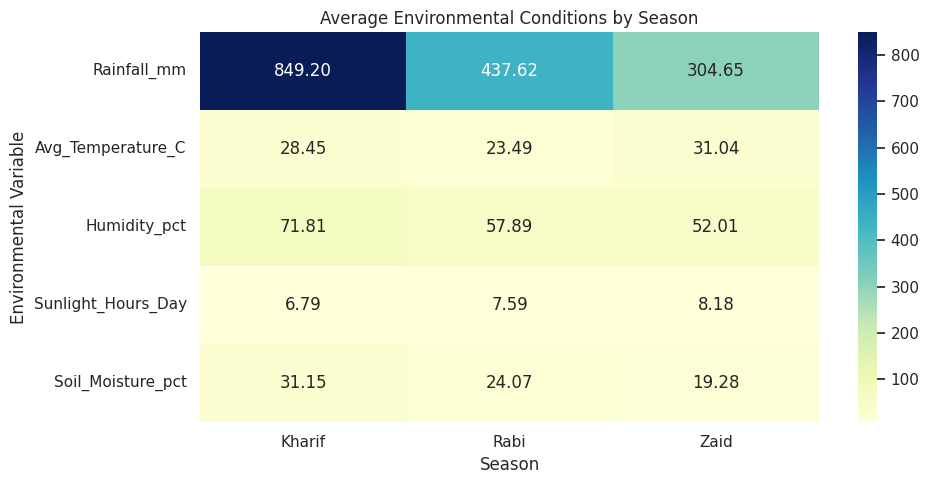

In [35]:
# Environmental conditions heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(season_env.T, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Average Environmental Conditions by Season")
plt.xlabel("Season")
plt.ylabel("Environmental Variable")
plt.tight_layout()
plt.show()


## 9. Agricultural Performance Across Seasons

The main performance indicators are **yield per hectare** and **total production**. Because yield contains some very large observations, both mean and median are examined.

In [36]:
performance_cols = [
    "Yield_Tonnes_Ha", "Production_Tonnes",
    "Water_Efficiency_t_per_1000m3", "Disease_Pest_Risk_pct"
]

season_performance = df_clean.groupby("Season")[performance_cols].agg(["mean", "median"]).reindex(
    ["Kharif", "Rabi", "Zaid"]
)
season_performance.round(2)

Yield_Tonnes_Ha        Production_Tonnes         \
                  mean median              mean median   
Season                                                   
Kharif            5.63   1.94             46.31  13.24   
Rabi              5.04   1.67             41.49  11.08   
Zaid              4.64   1.46             38.89   9.97   

       Water_Efficiency_t_per_1000m3        Disease_Pest_Risk_pct         
                                mean median                  mean median  
Season                                                                    
Kharif                          5.89   3.28                 54.47   54.5  
Rabi                            5.19   2.74                 40.48   40.6  
Zaid                            4.41   2.30                 38.22   37.9

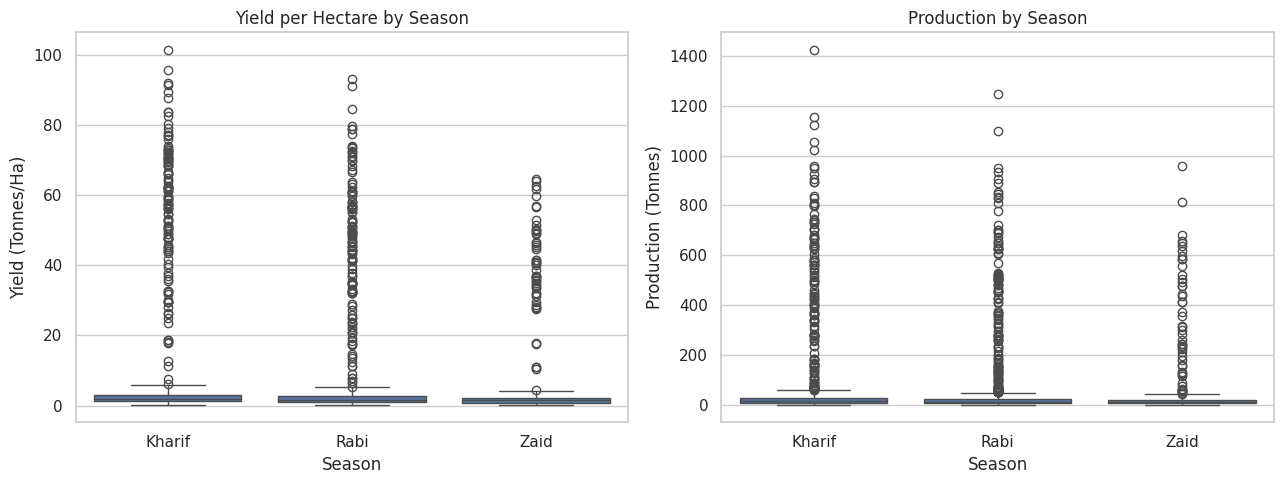

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df_clean, x="Season", y="Yield_Tonnes_Ha",
            order=["Kharif", "Rabi", "Zaid"], ax=axes[0])
axes[0].set_title("Yield per Hectare by Season")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Yield (Tonnes/Ha)")

sns.boxplot(data=df_clean, x="Season", y="Production_Tonnes",
            order=["Kharif", "Rabi", "Zaid"], ax=axes[1])
axes[1].set_title("Production by Season")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Production (Tonnes)")

plt.tight_layout()
plt.show()


### Important interpretation note
Yield and production are not the same measure. **Yield** is normalized by farm area (tonnes/ha), while **production** depends on both yield and farm area. Therefore, both should be considered when discussing agricultural performance.


## 10. Crop-Wise Seasonal Comparison

This helps determine whether the overall seasonal pattern is consistent across crop categories.

In [38]:
crop_season_yield = (
    df_clean.groupby(["Season", "Crop"])["Yield_Tonnes_Ha"]
    .mean()
    .unstack()
    .reindex(["Kharif", "Rabi", "Zaid"])
)

crop_season_yield.round(2)

Crop,Chilli,Cotton,Groundnut,Maize,Pulses,Rice,Sugarcane,Wheat
Season,,,,,,,,
Kharif,1.73,1.37,1.48,2.97,1.04,2.70,53.46,2.25
Rabi,1.47,1.20,1.23,2.60,0.88,2.32,43.29,2.06
Zaid,1.20,0.96,1.04,2.29,0.67,1.90,38.42,1.75


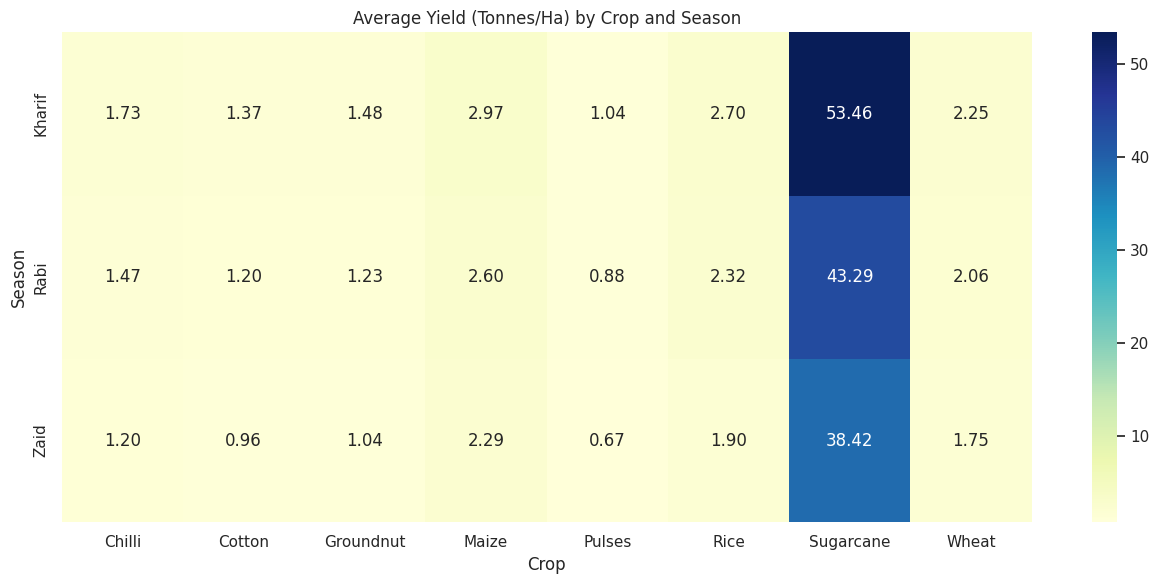

In [39]:
plt.figure(figsize=(13, 6))
sns.heatmap(crop_season_yield, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Average Yield (Tonnes/Ha) by Crop and Season")
plt.xlabel("Crop")
plt.ylabel("Season")
plt.tight_layout()
plt.show()

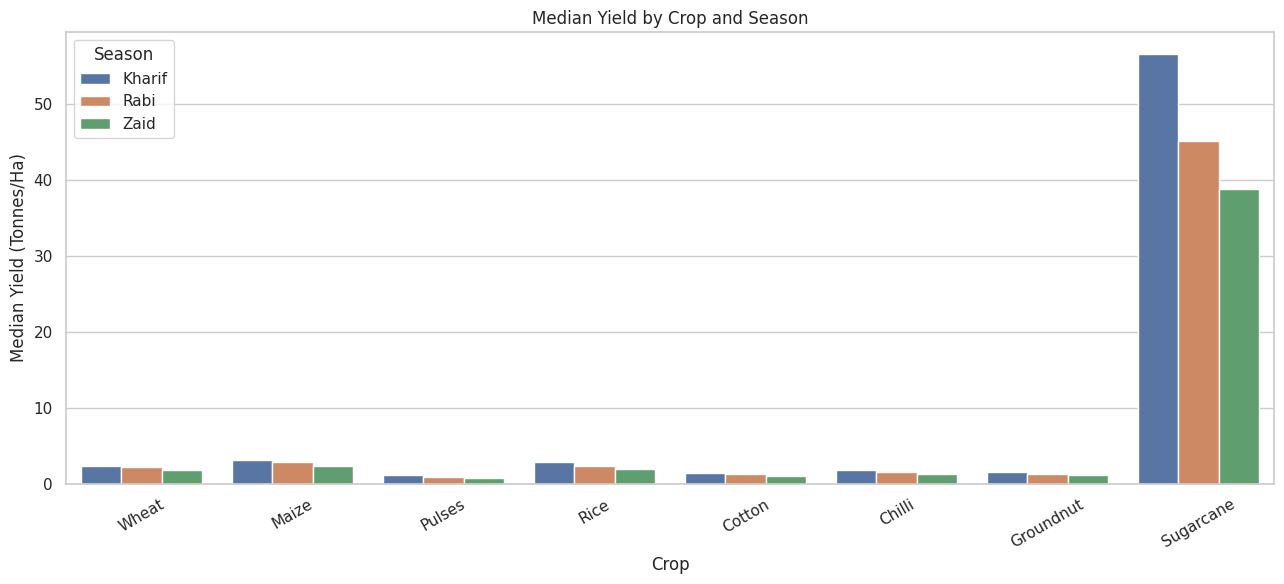

In [40]:
# Crop-wise yield comparison
plt.figure(figsize=(13, 6))
sns.barplot(
    data=df_clean,
    x="Crop",
    y="Yield_Tonnes_Ha",
    hue="Season",
    estimator="median",
    errorbar=None
)
plt.title("Median Yield by Crop and Season")
plt.xlabel("Crop")
plt.ylabel("Median Yield (Tonnes/Ha)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 11. Farming Practices and Resource Usage

Investigate fertilizer, pesticide, irrigation and water usage across seasons.

In [42]:
resource_cols = [
    "Fertilizer_kg_ha", "Pesticide_Litre_ha",
    "Water_Used_m3", "Water_Efficiency_t_per_1000m3"
]

season_resources = df_clean.groupby("Season")[resource_cols].mean().reindex(["Kharif", "Rabi", "Zaid"])
display(season_resources.round(2))


,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,,
Kharif,187.08,5.08,6102.20,5.89
Rabi,185.41,5.02,5846.99,5.19
Zaid,184.64,5.17,6419.89,4.41


Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.77,33.16,26.03,18.04
Rabi,22.74,32.33,26.92,18.01
Zaid,23.57,32.66,23.57,20.20


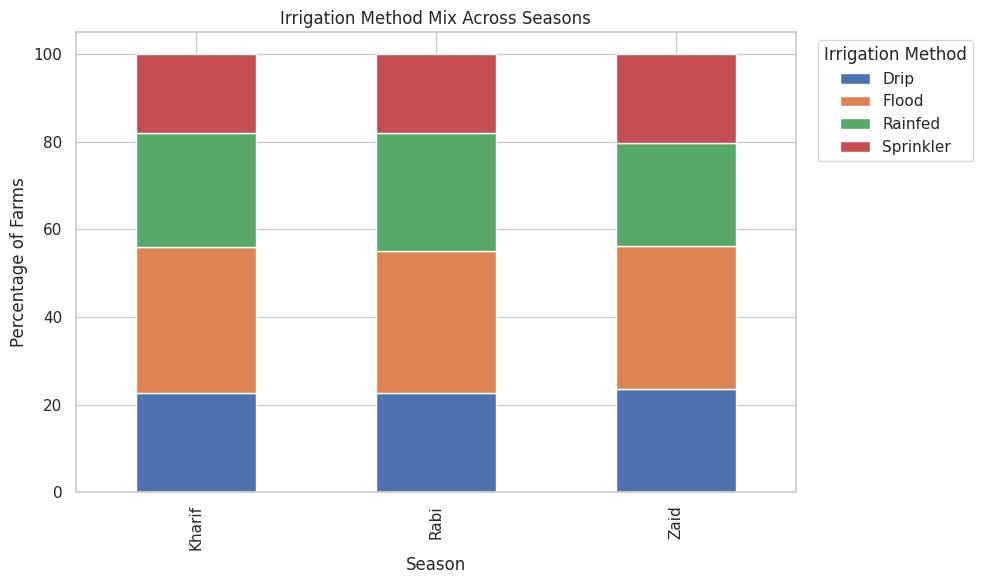

In [43]:
# Irrigation method distribution by season
irrigation_pct = pd.crosstab(
    df_clean["Season"], df_clean["Irrigation_Method"], normalize="index"
).mul(100).reindex(["Kharif", "Rabi", "Zaid"])

display(irrigation_pct.round(2))

irrigation_pct.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Irrigation Method Mix Across Seasons")
plt.xlabel("Season")
plt.ylabel("Percentage of Farms")
plt.legend(title="Irrigation Method", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 12. Economic Performance Across Seasons

Compare market price, cost, revenue and profit. Profit is treated as the primary economic outcome.

In [44]:
economic_cols = [
    "Market_Price_INR_Tonne", "Total_Cost_INR",
    "Revenue_INR", "Profit_INR"
]

season_economics = df_clean.groupby("Season")[economic_cols].agg(["mean", "median"]).reindex(
    ["Kharif", "Rabi", "Zaid"]
)
season_economics.round(2)


Market_Price_INR_Tonne          Total_Cost_INR           Revenue_INR  \
                         mean   median           mean    median        mean   
Season                                                                        
Kharif               44850.91  25793.0      531804.41  524840.0   710719.06   
Rabi                 44747.97  26041.0      513836.58  506733.0   601526.05   
Zaid                 44212.03  25749.5      543976.73  534833.0   519171.90   

                 Profit_INR           
          median       mean   median  
Season                                
Kharif  520196.0  178914.65  38808.0  
Rabi    438156.0   87689.47  -3187.0  
Zaid    373700.5  -24804.82 -62144.0

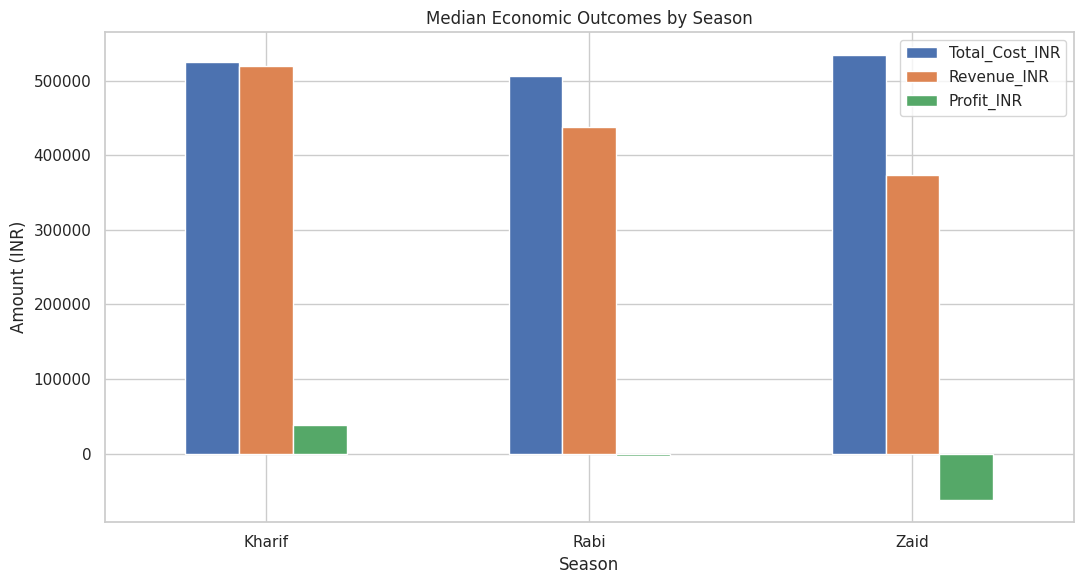

In [45]:
# Median economic outcomes
economic_medians = (
    df_clean.groupby("Season")[["Total_Cost_INR", "Revenue_INR", "Profit_INR"]]
    .median()
    .reindex(["Kharif", "Rabi", "Zaid"])
)

economic_medians.plot(kind="bar", figsize=(11, 6))
plt.title("Median Economic Outcomes by Season")
plt.xlabel("Season")
plt.ylabel("Amount (INR)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


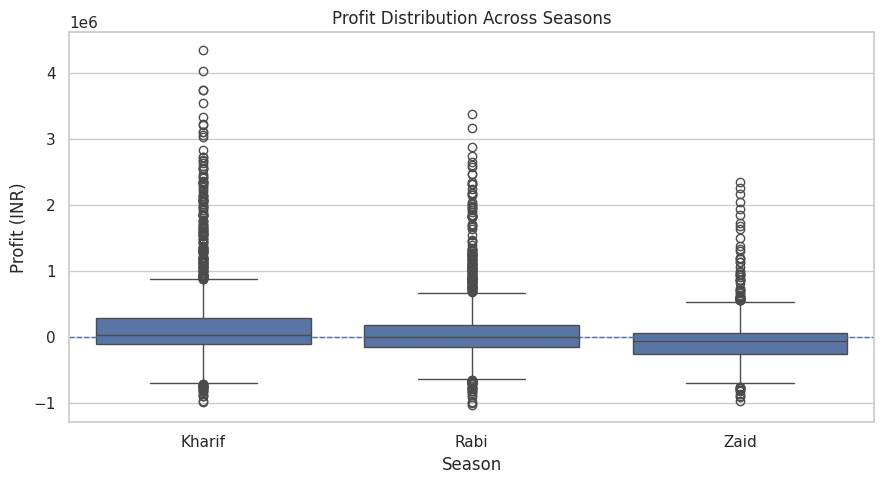

In [46]:
# Profit distribution
plt.figure(figsize=(9, 5))
sns.boxplot(data=df_clean, x="Season", y="Profit_INR",
            order=["Kharif", "Rabi", "Zaid"])
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Profit Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()


## 12. Multivariate Analysis

Multivariate analysis considers several variables together. The following seasonal profile combines yield, profit, rainfall, water use and disease/pest risk. A second visualization examines yield and profit while incorporating season and disease/pest risk.

,Median_Yield,Median_Profit,Mean_Rainfall,Mean_Water_Used,Mean_Disease_Risk
Season,,,,,
Kharif,1.94,38808.0,849.20,6102.20,54.47
Rabi,1.67,-3187.0,437.62,5846.99,40.48
Zaid,1.46,-62144.0,304.65,6419.89,38.22


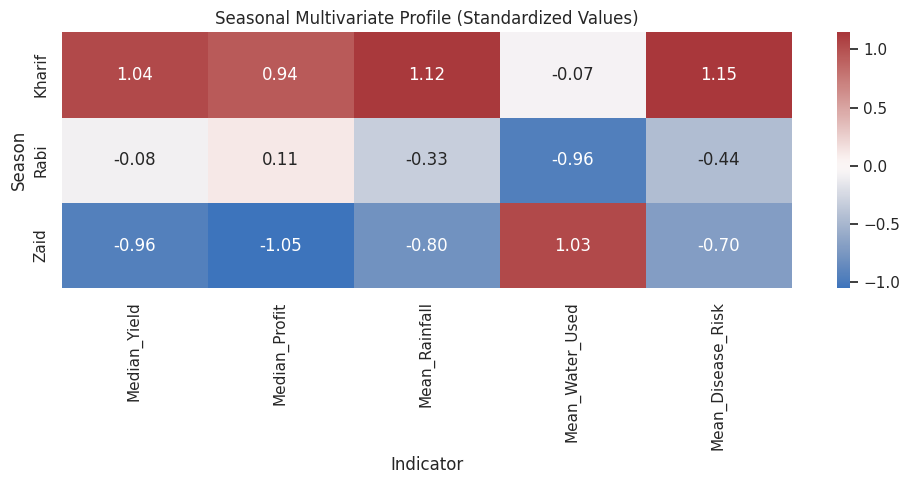

In [47]:
# Seasonal multivariate profile
multi_profile = (
    df_clean.groupby("Season")
    .agg(
        Median_Yield=("Yield_Tonnes_Ha", "median"),
        Median_Profit=("Profit_INR", "median"),
        Mean_Rainfall=("Rainfall_mm", "mean"),
        Mean_Water_Used=("Water_Used_m3", "mean"),
        Mean_Disease_Risk=("Disease_Pest_Risk_pct", "mean")
    )
    .reindex(season_order)
)
display(multi_profile.round(2))

# Standardized profile to compare indicators with different units
profile_z = (multi_profile - multi_profile.mean()) / multi_profile.std()

plt.figure(figsize=(10, 5))
sns.heatmap(profile_z, annot=True, fmt=".2f", center=0, cmap="vlag")
plt.title("Seasonal Multivariate Profile (Standardized Values)")
plt.xlabel("Indicator")
plt.ylabel("Season")
plt.tight_layout()
plt.show()

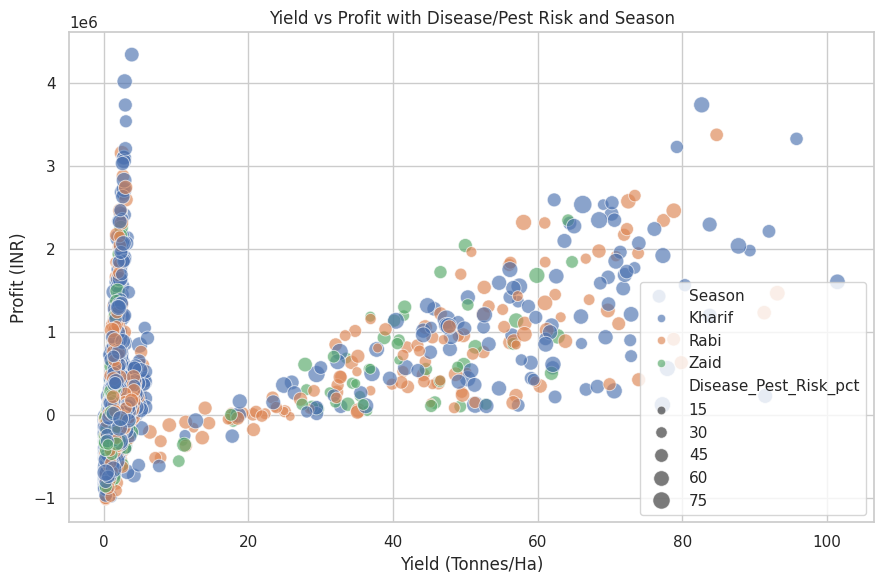

In [48]:
# Yield vs profit while incorporating season and disease/pest risk
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_clean,
    x="Yield_Tonnes_Ha",
    y="Profit_INR",
    hue="Season",
    size="Disease_Pest_Risk_pct",
    sizes=(20, 180),
    alpha=0.65
)
plt.title("Yield vs Profit with Disease/Pest Risk and Season")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

## 13. Correlation Analysis and Relationships

Spearman correlation is used because several variables are skewed and contain extreme observations. It measures monotonic relationships rather than assuming a linear relationship.

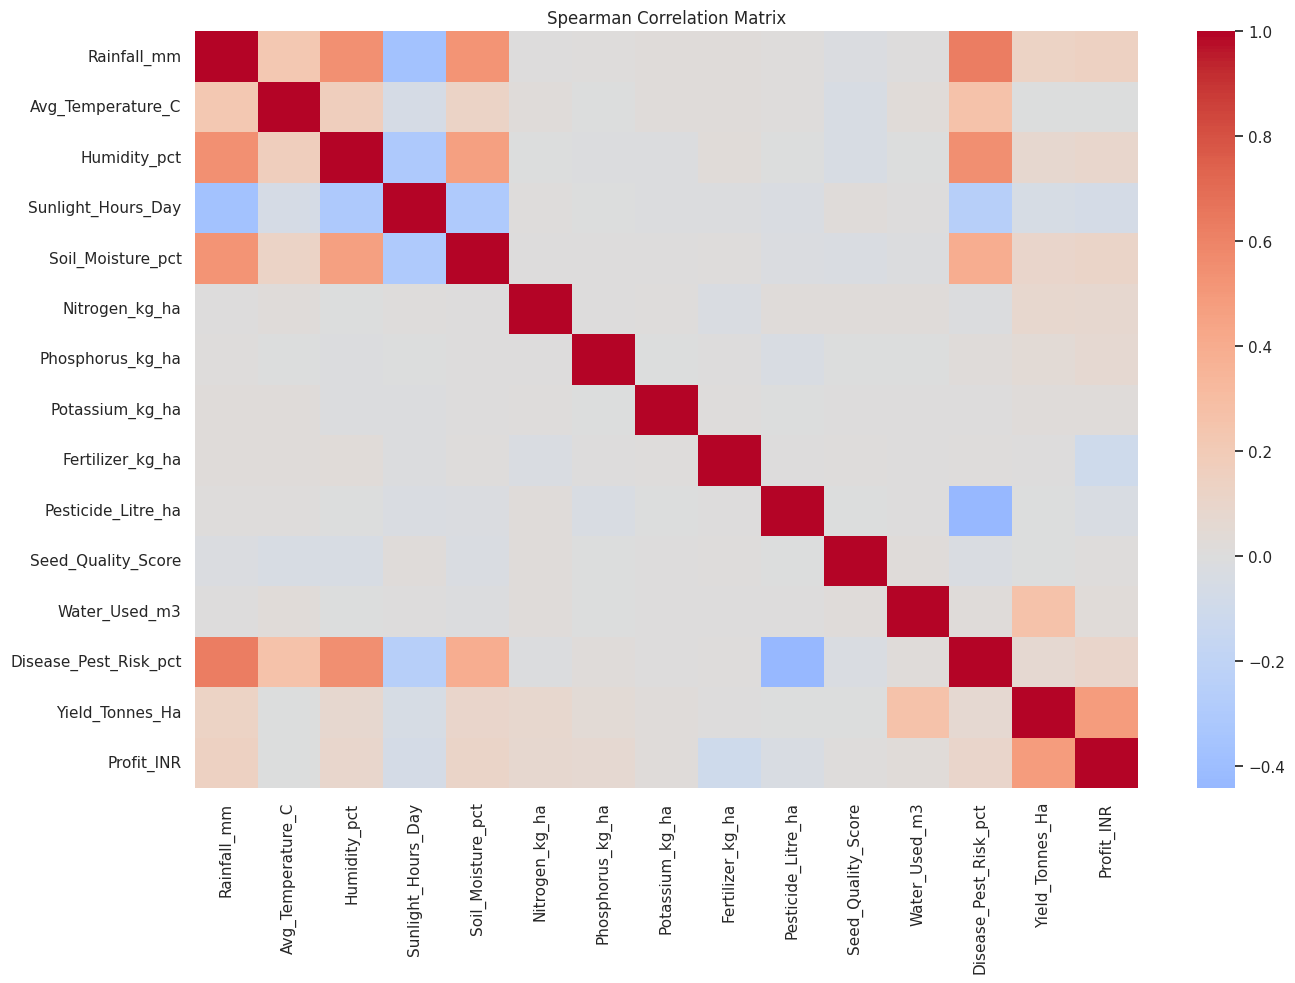

In [49]:
relationship_cols = [
    "Rainfall_mm", "Avg_Temperature_C", "Humidity_pct",
    "Sunlight_Hours_Day", "Soil_Moisture_pct",
    "Nitrogen_kg_ha", "Phosphorus_kg_ha", "Potassium_kg_ha",
    "Fertilizer_kg_ha", "Pesticide_Litre_ha",
    "Seed_Quality_Score", "Water_Used_m3",
    "Disease_Pest_Risk_pct", "Yield_Tonnes_Ha", "Profit_INR"
]

corr = df_clean[relationship_cols].corr(method="spearman")

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Spearman Correlation Matrix")
plt.tight_layout()
plt.show()

In [50]:
# Top correlations with yield and profit
yield_corr = corr["Yield_Tonnes_Ha"].drop("Yield_Tonnes_Ha").abs().sort_values(ascending=False)
profit_corr = corr["Profit_INR"].drop("Profit_INR").abs().sort_values(ascending=False)

print("Variables with strongest absolute Spearman association with Yield:")
display(yield_corr.head(8).to_frame("Absolute Correlation"))

print("Variables with strongest absolute Spearman association with Profit:")
display(profit_corr.head(8).to_frame("Absolute Correlation"))


Variables with strongest absolute Spearman association with Yield:


,Absolute Correlation
Profit_INR,0.489080
Water_Used_m3,0.264172
Rainfall_mm,0.129801
Soil_Moisture_pct,0.096536
Nitrogen_kg_ha,0.081694
Humidity_pct,0.080804
Disease_Pest_Risk_pct,0.064825
Sunlight_Hours_Day,0.051370


Variables with strongest absolute Spearman association with Profit:


,Absolute Correlation
Yield_Tonnes_Ha,0.489080
Rainfall_mm,0.144123
Soil_Moisture_pct,0.110578
Fertilizer_kg_ha,0.101745
Disease_Pest_Risk_pct,0.096998
Humidity_pct,0.090433
Nitrogen_kg_ha,0.076997
Phosphorus_kg_ha,0.069375


## 14. Statistical Validation of Seasonal Differences

A **Kruskal–Wallis test** checks whether the distributions of an outcome differ across the three seasons. This non-parametric test is appropriate when the data may not follow a normal distribution.

- **H₀:** The outcome distributions are the same across seasons.
- **H₁:** At least one season differs.
- A p-value below 0.05 is treated as evidence of a statistically significant difference.

In [52]:
from scipy.stats import kruskal

def kruskal_by_season(data, column):
    groups = [
        data.loc[data["Season"] == season, column]
        for season in ["Kharif", "Rabi", "Zaid"]
    ]
    h_stat, p_value = kruskal(*groups)
    return h_stat, p_value

test_cols = [
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Profit_INR",
    "Water_Used_m3",
    "Disease_Pest_Risk_pct"
]

results = []
for col in test_cols:
    h, p = kruskal_by_season(df_clean, col)
    results.append({
        "Metric": col,
        "Kruskal-Wallis H": h,
        "p-value": p,
        "Significant at 0.05": "Yes" if p < 0.05 else "No"
    })

kw_results = pd.DataFrame(results)
display(kw_results)

,Metric,Kruskal-Wallis H,p-value,Significant at 0.05
0,Yield_Tonnes_Ha,68.713067,1.199905e-15,Yes
1,Production_Tonnes,26.102557,2.147344e-06,Yes
2,Profit_INR,101.926055,7.362722e-23,Yes
3,Water_Used_m3,5.968897,5.056738e-02,No
4,Disease_Pest_Risk_pct,1430.910134,1.913429e-311,Yes


## 15. Regional Comparison

Seasonal effects may not be identical across all locations. Compare median yield by state and season to identify regional differences.


In [53]:
state_season_yield = (
    df_clean.groupby(["State", "Season"])["Yield_Tonnes_Ha"]
    .median()
    .unstack()
)

display(state_season_yield.round(2))


Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,2.04,1.35,1.58
Gujarat,1.80,1.59,1.62
Karnataka,1.98,1.68,1.33
Madhya Pradesh,1.98,1.59,1.38
Maharashtra,2.01,1.65,1.42
Punjab,1.86,1.87,1.33
Tamil Nadu,1.72,1.82,1.45
Telangana,2.10,1.74,1.46


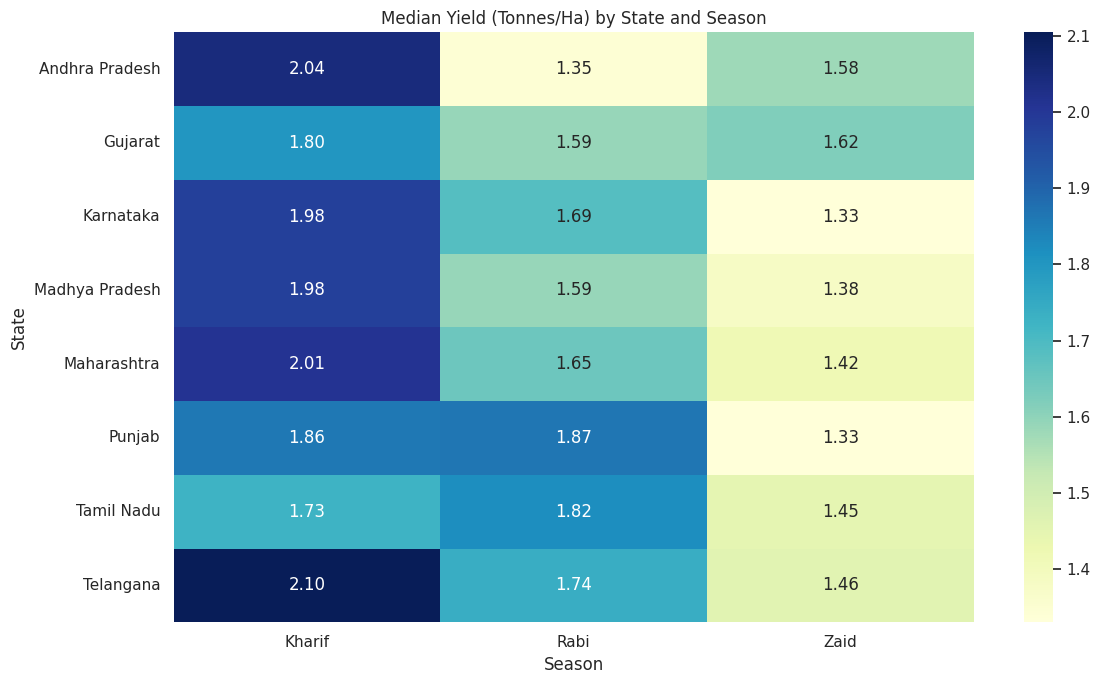

In [54]:
plt.figure(figsize=(12, 7))
sns.heatmap(state_season_yield, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Median Yield (Tonnes/Ha) by State and Season")
plt.xlabel("Season")
plt.ylabel("State")
plt.tight_layout()
plt.show()


## 16. Student-Designed Analyses

The project requires at least three student-designed analyses. Four focused analyses are included here:

1. **Crop × Season Performance** — identify the strongest crop-season combinations by median yield.
2. **Irrigation Method × Season** — compare the irrigation-method mix across seasons.
3. **Resource Use × Yield** — examine the association of fertilizer, water and pesticide use with yield.
4. **State × Season** — check whether seasonal yield patterns are consistent across states.

In [55]:
# Student-Designed Analysis 1: crop-season performance
crop_season_rank = (
    df_clean.groupby(["Crop", "Season"])["Yield_Tonnes_Ha"]
    .median()
    .reset_index()
    .sort_values("Yield_Tonnes_Ha", ascending=False)
)

print("Top 10 crop-season combinations by median yield:")
display(crop_season_rank.head(10).round(2))

Top 10 crop-season combinations by median yield:


,Crop,Season,Yield_Tonnes_Ha
18,Sugarcane,Kharif,56.65
19,Sugarcane,Rabi,45.21
20,Sugarcane,Zaid,38.78
9,Maize,Kharif,3.12
15,Rice,Kharif,2.86
10,Maize,Rabi,2.78
16,Rice,Rabi,2.37
21,Wheat,Kharif,2.36
11,Maize,Zaid,2.26
22,Wheat,Rabi,2.22


Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.77,33.16,26.03,18.04
Rabi,22.74,32.33,26.92,18.01
Zaid,23.57,32.66,23.57,20.20


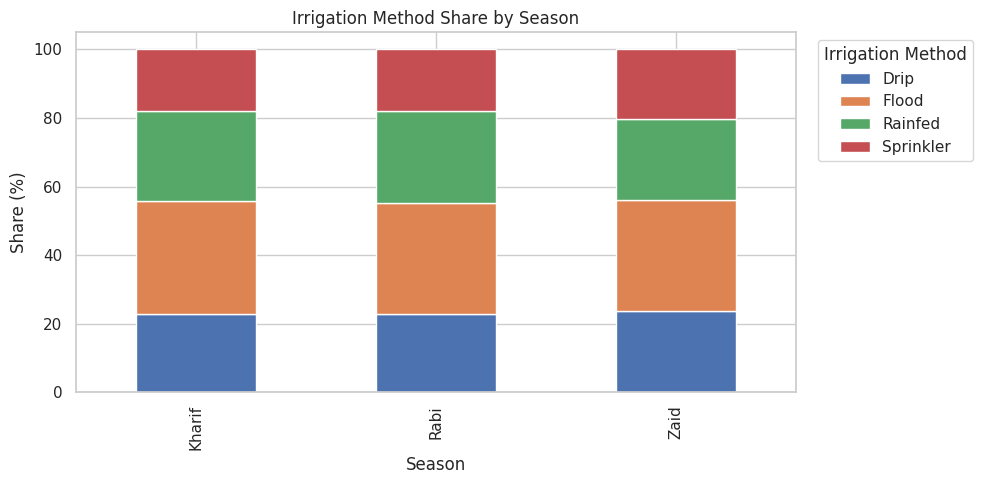

In [56]:
# Student-Designed Analysis 2: irrigation method mix by season
irrigation_share = (
    pd.crosstab(df_clean["Season"], df_clean["Irrigation_Method"], normalize="index")
    .mul(100)
    .reindex(season_order)
)
display(irrigation_share.round(2))

ax = irrigation_share.plot(kind="bar", stacked=True, figsize=(10, 5))
ax.set_title("Irrigation Method Share by Season")
ax.set_xlabel("Season")
ax.set_ylabel("Share (%)")
ax.legend(title="Irrigation Method", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [57]:
# Student-Designed Analysis 3: selected resource-use relationships with yield
resource_yield_corr = (
    df_clean[["Fertilizer_kg_ha", "Water_Used_m3", "Pesticide_Litre_ha", "Yield_Tonnes_Ha"]]
    .corr(method="spearman")["Yield_Tonnes_Ha"]
    .drop("Yield_Tonnes_Ha")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
display(resource_yield_corr.to_frame("Spearman Correlation").round(3))

,Spearman Correlation
Water_Used_m3,0.264
Fertilizer_kg_ha,0.004
Pesticide_Litre_ha,-0.000


Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,2.04,1.35,1.58
Gujarat,1.80,1.59,1.62
Karnataka,1.98,1.68,1.33
Madhya Pradesh,1.98,1.59,1.38
Maharashtra,2.01,1.65,1.42
Punjab,1.86,1.87,1.33
Tamil Nadu,1.72,1.82,1.45
Telangana,2.10,1.74,1.46


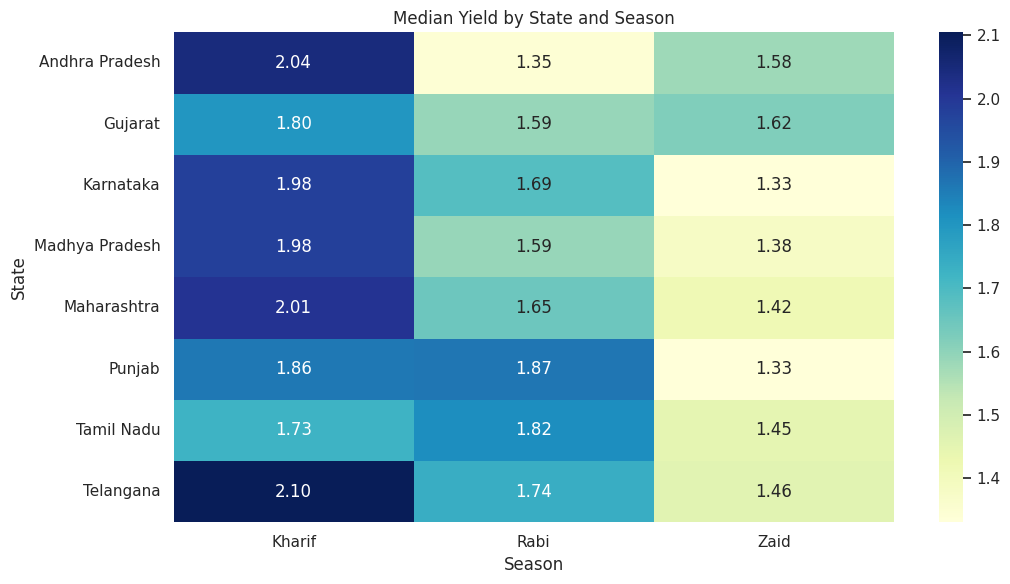

In [58]:
# Student-Designed Analysis 4: state-season yield variation
state_season_median = (
    df_clean.groupby(["State", "Season"])["Yield_Tonnes_Ha"]
    .median()
    .unstack()
    .reindex(columns=season_order)
)
display(state_season_median.round(2))

plt.figure(figsize=(11, 6))
sns.heatmap(state_season_median, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Median Yield by State and Season")
plt.xlabel("Season")
plt.ylabel("State")
plt.tight_layout()
plt.show()

## 17. Key Findings — 8+ Evidence-Based Insights

The findings below are generated from the cleaned dataset and the completed analyses. This keeps the final observations tied to actual values rather than generic statements.

In [61]:
# Generate evidence-based insights
season_counts = df_clean["Season"].value_counts().reindex(season_order)
season_median_yield = df_clean.groupby("Season")["Yield_Tonnes_Ha"].median().reindex(season_order)
season_mean_yield = df_clean.groupby("Season")["Yield_Tonnes_Ha"].mean().reindex(season_order)
season_median_profit = df_clean.groupby("Season")["Profit_INR"].median().reindex(season_order)
season_mean_rain = df_clean.groupby("Season")["Rainfall_mm"].mean().reindex(season_order)
season_mean_risk = df_clean.groupby("Season")["Disease_Pest_Risk_pct"].mean().reindex(season_order)
season_mean_water_eff = df_clean.groupby("Season")["Water_Efficiency_t_per_1000m3"].mean().reindex(season_order)

yield_corr_sorted = corr["Yield_Tonnes_Ha"].drop("Yield_Tonnes_Ha").sort_values(
    key=lambda s: s.abs(), ascending=False
)
profit_corr_sorted = corr["Profit_INR"].drop("Profit_INR").sort_values(
    key=lambda s: s.abs(), ascending=False
)

best_combo = crop_season_rank.iloc[0]

insights = [
    f"Season representation: {season_counts.idxmax()} has the most records ({season_counts.max():,}), while {season_counts.idxmin()} has the fewest ({season_counts.min():,}).",
    f"Median yield: {season_median_yield.idxmax()} has the highest median yield ({season_median_yield.max():,.2f} tonnes/ha), while {season_median_yield.idxmin()} has the lowest ({season_median_yield.min():,.2f} tonnes/ha).",
    f"Mean yield: {season_mean_yield.idxmax()} has the highest average yield ({season_mean_yield.max():,.2f} tonnes/ha). Mean and median should both be considered because the data contains extreme observations.",
    f"Rainfall: average rainfall is highest in {season_mean_rain.idxmax()} ({season_mean_rain.max():,.1f} mm) and lowest in {season_mean_rain.idxmin()} ({season_mean_rain.min():,.1f} mm).",
    f"Profitability: {season_median_profit.idxmax()} has the highest median profit (INR {season_median_profit.max():,.0f}), while {season_median_profit.idxmin()} has the lowest (INR {season_median_profit.min():,.0f}).",
    f"Disease/pest risk: average risk is highest in {season_mean_risk.idxmax()} ({season_mean_risk.max():,.2f}%) and lowest in {season_mean_risk.idxmin()} ({season_mean_risk.min():,.2f}%).",
    f"Water efficiency: {season_mean_water_eff.idxmax()} has the highest average water efficiency ({season_mean_water_eff.max():,.2f} tonnes per 1,000 m³).",
    f"Crop-season variation: {best_combo['Crop']} in {best_combo['Season']} has the highest median yield among the observed crop-season combinations ({best_combo['Yield_Tonnes_Ha']:.2f} tonnes/ha).",
    f"Yield relationship: {yield_corr_sorted.index[0]} has the strongest absolute Spearman relationship with yield among the tested variables (rho = {yield_corr_sorted.iloc[0]:.2f}).",
    f"Statistical testing: The Kruskal-Wallis test showed statistically significant seasonal differences in Yield, Production, Profit, and Disease/Pest Risk (p < 0.05), while Water Used did not show a statistically significant seasonal difference at the 5% significance level (p = 0.0506)."

]

for n, text in enumerate(insights, 1):
    print(f"{n}. {text}")

print(f"\nTotal documented insights: {len(insights)}")

1. Season representation: Kharif has the most records (1,779), while Zaid has the fewest (594).
2. Median yield: Kharif has the highest median yield (1.94 tonnes/ha), while Zaid has the lowest (1.46 tonnes/ha).
3. Mean yield: Kharif has the highest average yield (5.63 tonnes/ha). Mean and median should both be considered because the data contains extreme observations.
4. Rainfall: average rainfall is highest in Kharif (849.2 mm) and lowest in Zaid (304.7 mm).
5. Profitability: Kharif has the highest median profit (INR 38,808), while Zaid has the lowest (INR -62,144).
6. Disease/pest risk: average risk is highest in Kharif (54.47%) and lowest in Zaid (38.22%).
7. Water efficiency: Kharif has the highest average water efficiency (5.89 tonnes per 1,000 m³).
8. Crop-season variation: Sugarcane in Kharif has the highest median yield among the observed crop-season combinations (56.65 tonnes/ha).
9. Yield relationship: Profit_INR has the strongest absolute Spearman relationship with yield amo

## 18. Recommendations, Limitations and Final Conclusion

### Evidence-Based Recommendations

1. **Use season-specific planning:** Seasonal differences in rainfall, yield, risk and profitability suggest that farming decisions should consider the season.
2. **Prioritize water efficiency:** Compare water use with yield and water-efficiency measures when evaluating irrigation practices.
3. **Use crop-season evidence:** Evaluate crop performance within each season instead of relying only on overall crop averages.
4. **Strengthen disease and pest monitoring:** Seasons with higher observed risk should receive closer monitoring and preventive attention.
5. **Balance productivity with profitability:** Higher yield or production does not automatically mean higher profit; cost and revenue should also be considered.
6. **Treat statistical relationships carefully:** Correlation identifies association, not causation. Strong relationships should be investigated further using agricultural knowledge and additional data.

### Limitations

- The analysis is based only on the variables and records available in the supplied dataset.
- Seasonal comparisons describe the observed data and do not by themselves prove that season causes an outcome.
- IQR outlier detection is a screening method; an identified outlier may represent a genuine farming condition rather than an error.
- Correlation measures association and should not be interpreted as causal evidence.
- Other real-world factors may affect agricultural performance but may not be represented in the dataset.

### Final Conclusion

The analysis shows measurable differences across seasons in environmental conditions, resource usage, yield, disease/pest risk and economic outcomes. Combining data cleaning, descriptive statistics, univariate, bivariate and multivariate analysis, outlier investigation, correlation analysis, statistical testing and seasonal comparisons provides a structured view of agricultural performance.

The results can support more informed seasonal agricultural planning, while the limitations highlight the need for additional data and domain knowledge before making causal or universal claims.

## 19. Project Checklist Verification

This final section maps the notebook work to the required submission checklist.

In [60]:
# Final checklist coverage
checklist = {
    "Dataset loaded successfully": True,
    "Top 5 rows analyzed": True,
    "Dataset shape and structure examined": True,
    "Data types examined": True,
    "Missing values identified and handled": True,
    "Duplicate records identified and handled": True,
    "Descriptive/statistical analysis performed": True,
    "Outliers investigated": True,
    "Univariate analysis completed": True,
    "Bivariate analysis completed": True,
    "Multivariate analysis completed": True,
    "Correlation analysis completed": True,
    "Seasonal comparisons performed": True,
    "At least 3 student-designed analyses completed": True,
    "At least 8 meaningful insights documented": True,
    "Evidence-based recommendations provided": True,
    "Limitations discussed": True,
    "Final conclusion provided": True
}

check_df = pd.DataFrame({
    "Checklist Item": checklist.keys(),
    "Status": ["✓ Completed" if value else "Needs Work" for value in checklist.values()]
})
display(check_df)
print(f"Checklist coverage: {sum(checklist.values())}/{len(checklist)} items addressed in the notebook.")

,Checklist Item,Status
0,Dataset loaded successfully,✓ Completed
1,Top 5 rows analyzed,✓ Completed
2,Dataset shape and structure examined,✓ Completed
3,Data types examined,✓ Completed
4,Missing values identified and handled,✓ Completed
5,Duplicate records identified and handled,✓ Completed
6,Descriptive/statistical analysis performed,✓ Completed
7,Outliers investigated,✓ Completed
8,Univariate analysis completed,✓ Completed
9,Bivariate analysis completed,✓ Completed


Checklist coverage: 18/18 items addressed in the notebook.
